In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression

In [61]:
df_copy = pd.read_csv(r'C:\Users\Tanvi\GitHub\Kaggle_datasets\spaceship_titanic\data\train.csv')
df = df_copy
print(df.describe())
print(df.info())


               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 co

In [62]:
# Cleaning
df['Age'] = df['Age'].fillna(df['Age'].median())
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
df['RoomService'] = df['RoomService'].fillna(df['RoomService'].median())
df['FoodCourt'] = df['FoodCourt'].fillna(df['FoodCourt'].median())
df['ShoppingMall'] = df['ShoppingMall'].fillna(df['ShoppingMall'].median())
df['Spa'] = df['Spa'].fillna(df['Spa'].median())
df['VRDeck'] = df['VRDeck'].fillna(df['VRDeck'].median())
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])
df['Name'] = df['Name'].fillna(df['Name'].mode()[0])    
df.drop_duplicates(inplace=True)
df.dropna()

print(df.isnull().sum())

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64


C:\Users\Tanvi\AppData\Local\Temp\ipykernel_3180\3035921922.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
C:\Users\Tanvi\AppData\Local\Temp\ipykernel_3180\3035921922.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])


In [63]:
print(df['Cabin'])

0          B/0/P
1          F/0/S
2          A/0/S
3          A/0/S
4          F/1/S
          ...   
8688      A/98/P
8689    G/1499/S
8690    G/1500/S
8691     E/608/S
8692     E/608/S
Name: Cabin, Length: 8693, dtype: object


In [64]:
df['Transported'] = df['Transported'].astype(int)
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)
df['HomePlanet'] = df['HomePlanet'].map({'Earth': 0, 'Europa': 1, 'Mars': 2})
df['Destination'] = df['Destination'].map({'TRAPPIST-1e': 0, 'PSO J318.5-22': 1, '55 Cancri e': 2})
df['Cabin_deck'] = df['Cabin'].str.split('/').str[0].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'T': 7})
df['Cabin_num'] = df['Cabin'].str.split('/').str[1].astype(int)
df['Cabin_side'] = df['Cabin'].str.split('/').str[2].map({'P': 0, 'S': 1})
df.drop('Name', axis=1, inplace=True)
df.drop('Cabin', axis=1, inplace=True)


In [65]:
df 


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_deck,Cabin_num,Cabin_side
0,0001_01,1,0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
1,0002_01,0,0,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1,5,0,1
2,0003_01,1,0,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,0,0,1
3,0003_02,1,0,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,0,0,1
4,0004_01,0,0,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1,5,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,1,0,2,41.0,1,0.0,6819.0,0.0,1643.0,74.0,0,0,98,0
8689,9278_01,0,1,1,18.0,0,0.0,0.0,0.0,0.0,0.0,0,6,1499,1
8690,9279_01,0,0,0,26.0,0,0.0,0.0,1872.0,1.0,0.0,1,6,1500,1
8691,9280_01,1,0,2,32.0,0,0.0,1049.0,0.0,353.0,3235.0,0,4,608,1


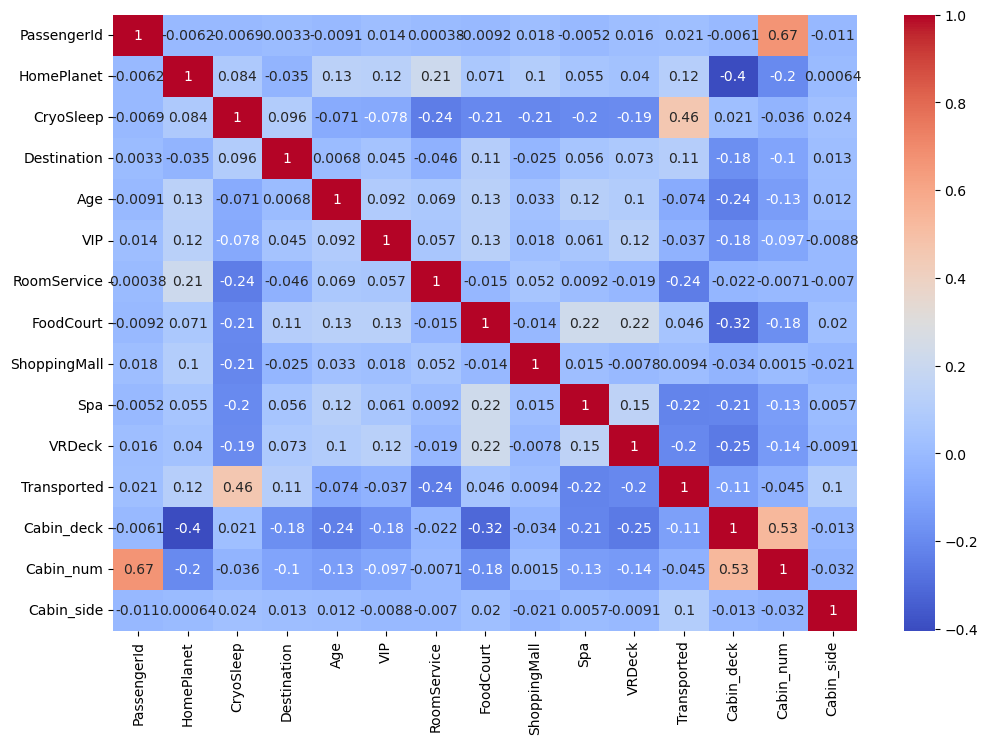

In [66]:
corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [67]:
df.drop('Age', axis=1, inplace=True)
df.drop('Cabin_deck', axis=1, inplace=True)
df.drop('Cabin_num', axis=1, inplace=True)

df.drop('VRDeck', axis=1, inplace=True)
df.drop('RoomService', axis=1, inplace=True)

df.drop('Spa', axis=1, inplace=True)
df.drop('VIP', axis=1, inplace=True)


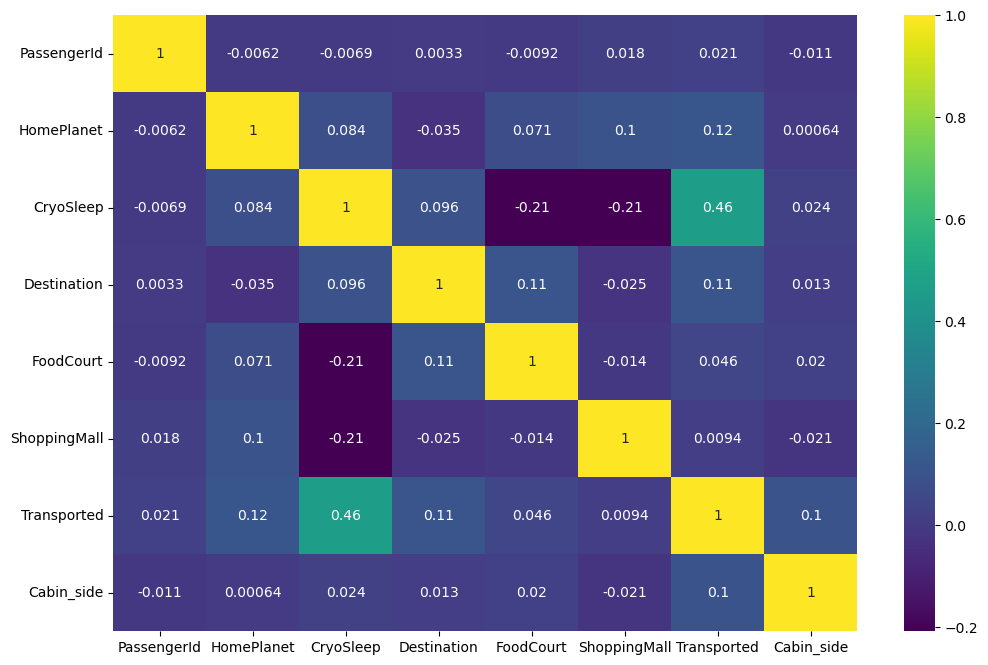

In [68]:


corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='viridis')
plt.show()

ValueError: Could not interpret value `CryosleepCabin_side` for `x`. An entry with this name does not appear in `data`.

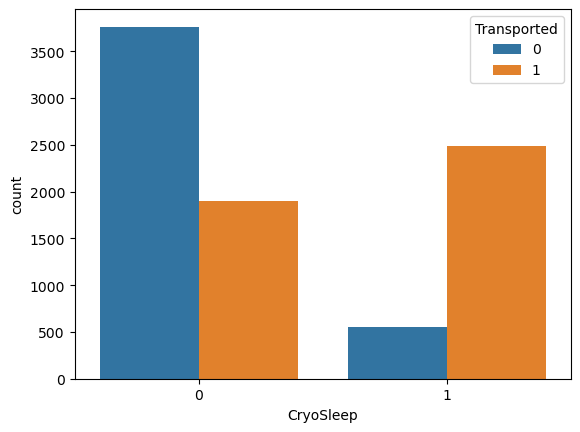

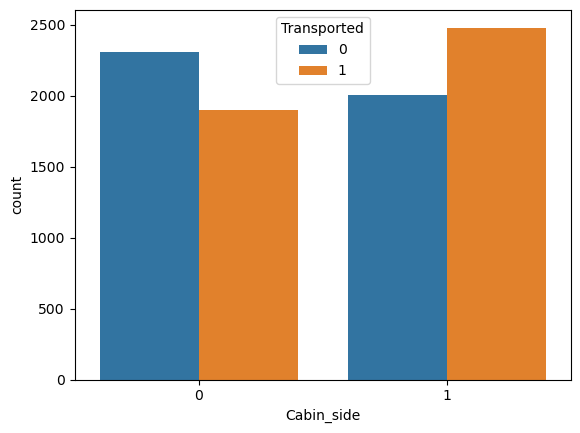

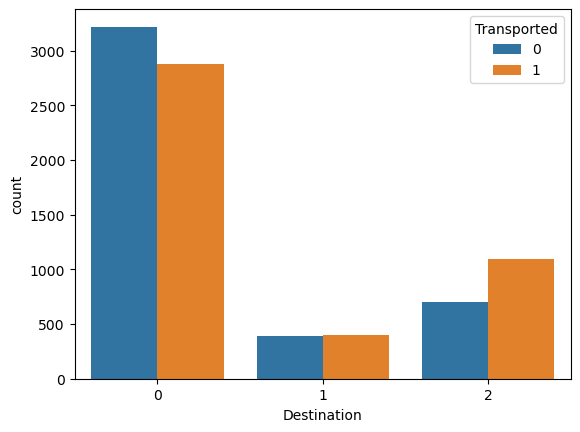

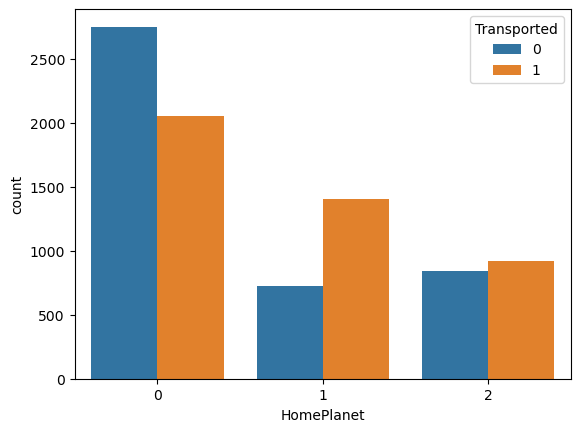

c:\Users\Tanvi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


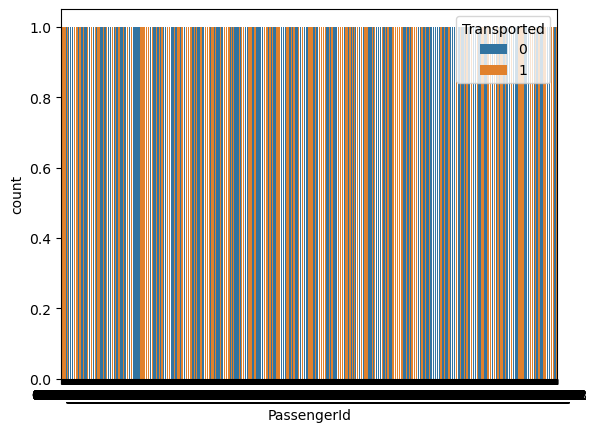

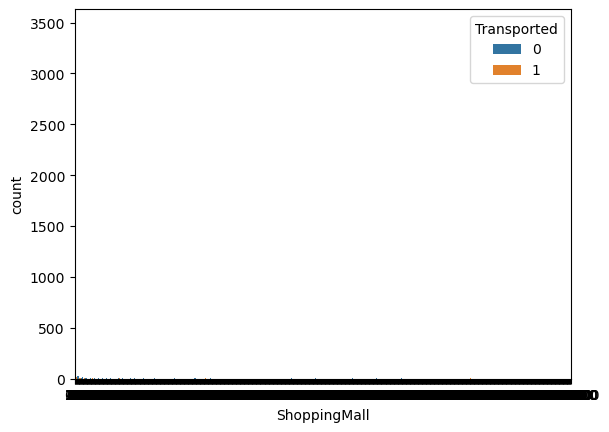

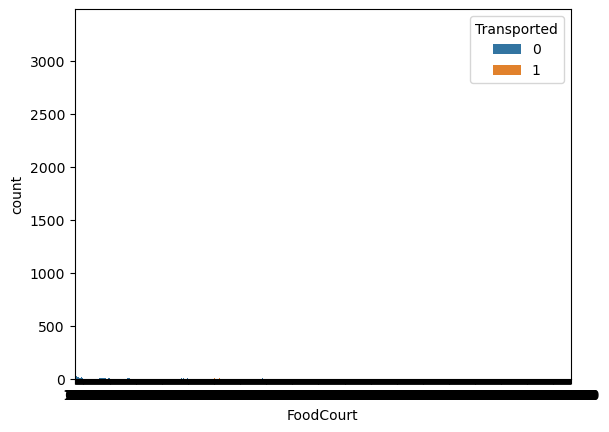

In [71]:
sns.countplot(data=df, x='CryoSleep', hue='Transported')
plt.show()
sns.countplot(data=df, x='Cabin_side', hue='Transported')
plt.show()
sns.countplot(data=df, x='Destination', hue='Transported')
plt.show()
sns.countplot(data=df, x='HomePlanet', hue='Transported')
plt.show()
sns.countplot(data=df, x='PassengerId', hue='Transported')
plt.show()
sns.countplot(data=df, x='ShoppingMall', hue='Transported')
plt.show()
sns.countplot(data=df, x='FoodCourt', hue='Transported')
plt.show()









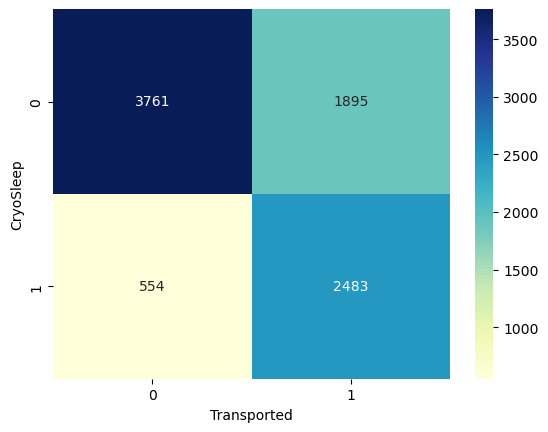

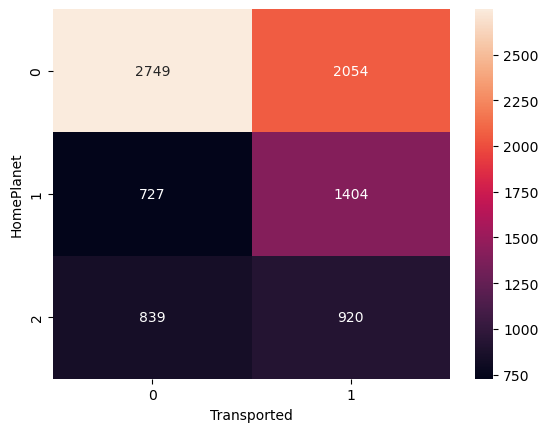

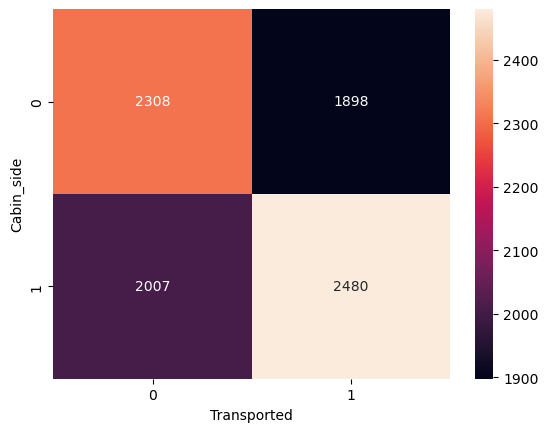

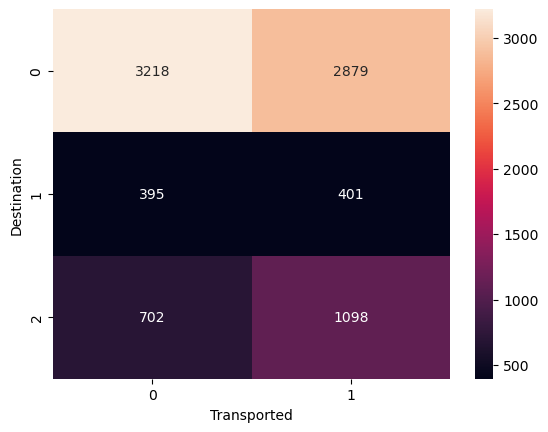

In [78]:
ct = pd.crosstab(df['CryoSleep'], df['Transported'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.show()

ct = pd.crosstab(df['HomePlanet'], df['Transported'])
sns.heatmap(ct, annot=True, fmt='d')
plt.show()

ct = pd.crosstab(df['Cabin_side'], df['Transported'])
sns.heatmap(ct, annot=True, fmt='d')
plt.show()

ct = pd.crosstab(df['Destination'], df['Transported'])
sns.heatmap(ct, annot=True, fmt='d')
plt.show()



